Generating Production Orchestration Flowchart...


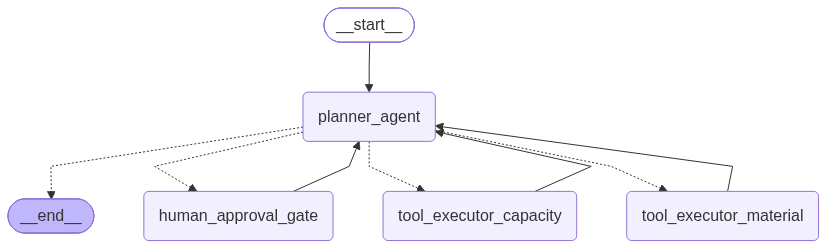


--- Starting Orchestration Execution ---
Node Executed: planner_agent
Message: Checking machine capacity...

Node Executed: tool_executor_capacity
Message: Capacity check: Available. Machines can handle 1000 units.

Node Executed: planner_agent
Message: Checking material inventory...

Node Executed: tool_executor_material
Message: Material check: BOM BOM-992 materials are in stock.

Node Executed: planner_agent
Message: Drafted Schedule:
Proposed Schedule: Shift 1 (50%), Shift 2 (50%) for 1000 units.
Requesting human approval to commit.


--- HUMAN APPROVAL REQUIRED ---
Agent wants to commit a new production schedule to the MES.
Human Action: Approved
-------------------------------

Node Executed: human_approval_gate
Node Executed: planner_agent
Message: Schedule committed to MES successfully.



In [1]:
# ---------------------------------------------------------
# 03_Production_Orchestration_Agent.ipynb
# LangGraph Implementation for Production Scheduling
# ---------------------------------------------------------

import operator
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage
from langgraph.graph import StateGraph, END, START
from IPython.display import Image, display

# 1. Define the Graph State
class OrchestrationState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    capacity_checked: bool
    material_checked: bool
    schedule_proposed: bool
    approval_status: str # Maps to workflow_history.approval_status
    next_step: str

# 2. Mocking the MES & ERP Tools (Mapped to backend_api_table in production)
def check_machine_capacity(target_output: int) -> str:
    """Checks if machines have the capacity for the target output."""
    return f"Capacity check: Available. Machines can handle {target_output} units."

def check_material_inventory(bom_id: str) -> str:
    """Checks ERP/Inventory for raw material availability."""
    return f"Material check: BOM {bom_id} materials are in stock."

def propose_schedule(target_output: int) -> str:
    """Drafts the production schedule based on capacity and materials."""
    return f"Proposed Schedule: Shift 1 (50%), Shift 2 (50%) for {target_output} units."

# 3. Define the Nodes
def planner_agent(state: OrchestrationState):
    """
    Node 1: The Orchestration Planner.
    Evaluates what checks have been completed and decides the next action.
    """
    # If starting fresh, check capacity
    if not state.get('capacity_checked'):
        return {
            "messages": [AIMessage(content="Checking machine capacity...", tool_calls=[{"name": "check_machine_capacity", "args": {"target_output": 1000}, "id": "call_cap1"}])],
            "next_step": "execute_capacity"
        }
    
    # If capacity is good, check materials
    elif not state.get('material_checked'):
        return {
            "messages": [AIMessage(content="Checking material inventory...", tool_calls=[{"name": "check_material_inventory", "args": {"bom_id": "BOM-992"}, "id": "call_mat1"}])],
            "next_step": "execute_material"
        }
    
    # If both are checked, propose schedule and ask for approval
    elif not state.get('schedule_proposed'):
        schedule = propose_schedule(1000)
        return {
            "messages": [AIMessage(content=f"Drafted Schedule:\n{schedule}\nRequesting human approval to commit.")],
            "schedule_proposed": True,
            "approval_status": "Pending",
            "next_step": "human_approval"
        }
    
    # If approved, finalize
    elif state.get('approval_status') == 'Approved':
        return {
            "messages": [AIMessage(content="Schedule committed to MES successfully.")],
            "next_step": "end"
        }

def tool_executor_capacity(state: OrchestrationState):
    """Node 2: Executes Capacity Check Tool"""
    last_msg = state['messages'][-1]
    tool_call = last_msg.tool_calls[0]
    result = check_machine_capacity(tool_call['args']['target_output'])
    
    return {
        "messages": [ToolMessage(content=result, tool_call_id=tool_call['id'])],
        "capacity_checked": True,
        "next_step": "planner"
    }

def tool_executor_material(state: OrchestrationState):
    """Node 3: Executes Material Check Tool"""
    last_msg = state['messages'][-1]
    tool_call = last_msg.tool_calls[0]
    result = check_material_inventory(tool_call['args']['bom_id'])
    
    return {
        "messages": [ToolMessage(content=result, tool_call_id=tool_call['id'])],
        "material_checked": True,
        "next_step": "planner"
    }

def human_approval_gate(state: OrchestrationState):
    """Node 4: Human-in-the-Loop for Schedule Commitment"""
    print("\n--- HUMAN APPROVAL REQUIRED ---")
    print("Agent wants to commit a new production schedule to the MES.")
    
    # Simulating a user clicking "Approve" in the Command Centre UI
    user_input = "Approved" 
    
    print(f"Human Action: {user_input}\n-------------------------------\n")
    return {"approval_status": user_input, "next_step": "planner"}

# 4. Define Routing Logic
def route_next_step(state: OrchestrationState):
    step = state.get("next_step")
    if step == "execute_capacity":
        return "tool_executor_capacity"
    elif step == "execute_material":
        return "tool_executor_material"
    elif step == "human_approval":
        return "human_approval_gate"
    elif step == "end":
        return END
    return "planner_agent"

# 5. Build the LangGraph
workflow = StateGraph(OrchestrationState)

workflow.add_node("planner_agent", planner_agent)
workflow.add_node("tool_executor_capacity", tool_executor_capacity)
workflow.add_node("tool_executor_material", tool_executor_material)
workflow.add_node("human_approval_gate", human_approval_gate)

workflow.add_edge(START, "planner_agent")

workflow.add_conditional_edges(
    "planner_agent",
    route_next_step,
    {
        "tool_executor_capacity": "tool_executor_capacity",
        "tool_executor_material": "tool_executor_material",
        "human_approval_gate": "human_approval_gate",
        END: END
    }
)

# Route tools back to the planner
workflow.add_edge("tool_executor_capacity", "planner_agent")
workflow.add_edge("tool_executor_material", "planner_agent")
workflow.add_edge("human_approval_gate", "planner_agent")

app = workflow.compile()

# 6. Render the Graph Visualization
print("Generating Production Orchestration Flowchart...")
display(Image(app.get_graph().draw_mermaid_png()))

# 7. Execute the Pipeline
print("\n--- Starting Orchestration Execution ---")
initial_state = {
    "messages": [HumanMessage(content="Schedule production for 1000 units of BOM-992.")],
    "capacity_checked": False,
    "material_checked": False,
    "schedule_proposed": False,
    "approval_status": "None",
    "next_step": ""
}

for output in app.stream(initial_state):
    for key, value in output.items():
        print(f"Node Executed: {key}")
        if "messages" in value:
            print(f"Message: {value['messages'][-1].content}\n")